In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler


    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file


/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_49505/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


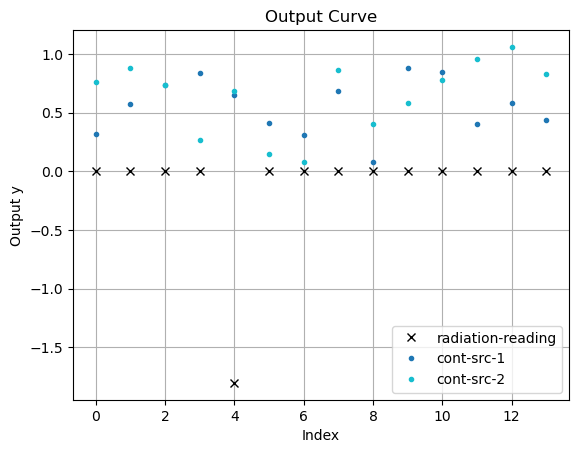

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
X = inputs
y = outputs

In [4]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []

In [5]:
param_grid = [
    {'method': 'PI', 'xi': 0.01},
    {'method': 'PI', 'xi': 0.05},
    {'method': 'PI', 'xi': 0.1},
    {'method': 'UCB', 'kappa': 1.0},
    {'method': 'UCB', 'kappa': 2.0},
    {'method': 'UCB', 'kappa': 3.0},
    {'method': 'EI', 'xi': 0.01},
    {'method': 'EI', 'xi': 0.05},
    {'method': 'EI', 'xi': 0.1},
]

# --- Shared precomputation ---
print("Starting acquisition sweep...")

# Shared config
apply_scaling = True
grid_size = 100
dimension = X.shape[1] - 1
filter_mode = 'gp'

print("Number of features:", X.shape[1])
y_scaled = preprocess_y(y, apply_scaling)
bounds = compute_bounds(X)
X_grid = create_nd_grid(bounds, grid_size, dimension)
X_grid_filtered = filter_grid(X, y_scaled, X_grid, filter_mode)
gp_model = train_gp(X, y_scaled)

mean, std = gp_model.predict(X_grid_filtered, return_std=True)
print("GP prediction stats:")
print("  Mean shape:", mean.shape)
print("  Std shape :", std.shape)

# --- Parameter sweep ---
for params in param_grid:
    method = params['method']
    xi = params.get('xi', 0.1)
    kappa = params.get('kappa', 2.0)
    label_param = xi if method in ['PI', 'EI'] else kappa

    next_point, acq_vals, _, _ = select_next_query_from_gp(
        X_grid=X_grid_filtered, y=y_scaled, method=method, xi=xi, kappa=kappa,
        mean=mean, std=std  # reuse cached predictions
    )
    score = acq_vals[np.argmax(acq_vals)]
    print(f"[{method} | {label_param}] → Next query point: {next_point}, Score: {score:.4f}")
    log_query_candidate(method, label_param, next_point, score)

Starting acquisition sweep...
Number of features: 2
Applying standard scaling to y.
Computing bounds with margin 0.1.
Bounds per feature: [(-0.017492748179194134, 0.983889828818117), (-0.02127722205028118, 1.159596)]
Creating 100^(2) grid.
Grid shape: (10000, 2)
Filtering grid using mode: gp
Grid shape before filtering: (10000, 2)
Filtered 220 candidates near decision boundary (|margin| < 0.2)
Excluded 9780 candidates from consideration
Final grid shape: (220, 2)
Filtered grid shape: (220, 2)
Using default RBF kernel.
GP model trained.
GP prediction stats:
  Mean shape: (220,)
  Std shape : (220,)
Using cached GP predictions.
Computing acquisition for method: PI
[PI | 0.01] → Next query point: [0.56917583 1.02838786], Score: 0.5893
Using cached GP predictions.
Computing acquisition for method: PI
[PI | 0.05] → Next query point: [0.57929081 1.01645985], Score: 0.5382
Using cached GP predictions.
Computing acquisition for method: PI
[PI | 0.1] → Next query point: [0.58940578 1.00453184],

In [6]:
find_best_candidate(query_results)

Total number of points to evaluate: 9
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([0.56917583, 1.02838786]), 'score': 0.5893000293421413, 'dim': 2}
{'method': 'PI', 'xi': 0.05, 'kappa': None, 'x': array([0.57929081, 1.01645985]), 'score': 0.538151035255017, 'dim': 2}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([0.58940578, 1.00453184]), 'score': 0.48597550152770375, 'dim': 2}
{'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([0.47814105, 1.0641719 ]), 'score': 0.9177205994692185, 'dim': 2}
{'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([0.47814105, 1.0641719 ]), 'score': 1.6212865592739771, 'dim': 2}
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([0.47814105, 1.0641719 ]), 'score': 2.324852519078736, 'dim': 2}
{'method': 'EI', 'xi': 0.01, 'kappa': None, 'x': array([0.3365314, 0.8733237]), 'score': 0.2470822920451076, 'dim': 2}
{'method': 'EI', 'xi': 0.05, 'kappa': None, 'x': array([0.3365314, 0.8733237]), 'score': 0.22817832144184116, 'dim': 2}

{'method': 'UCB',
 'xi': None,
 'kappa': 3.0,
 'x': array([0.47814105, 1.0641719 ]),
 'score': 2.324852519078736,
 'dim': 2}

In [7]:
#add points to dataframe
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    cont-src-1  cont-src-2  radiation-reading  source
2     0.731024    0.733000       7.710875e-16    file
7     0.683418    0.861057       2.535001e-40    file
1     0.574329    0.879898       1.033078e-46    file
9     0.883890    0.582254       6.229856e-48    file
0     0.319404    0.762959       1.322677e-79    file
8     0.082507    0.403488       3.606771e-81    file
3     0.840353    0.264732      3.341771e-124    file
12    0.579291    1.059596      4.507438e-133  week-3
11    0.404040    0.959596     -9.343448e-112  week-2
6     0.312691    0.078723      -2.089093e-91    file
13    0.436769    0.825163      -1.519972e-55  week-4
5     0.410437    0.147554      -2.159249e-54    file
10    0.848485    0.777778      -1.248783e-49  week-1
4     0.650114    0.681526      -3.606063e-03    file
14    0.569176    1.028388                NaN  week-x
15    0.579291    1.016460                NaN  week-x
16    0.589406    1.004532                NaN  week-x
17    0.478141    1.064172  

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_49505/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


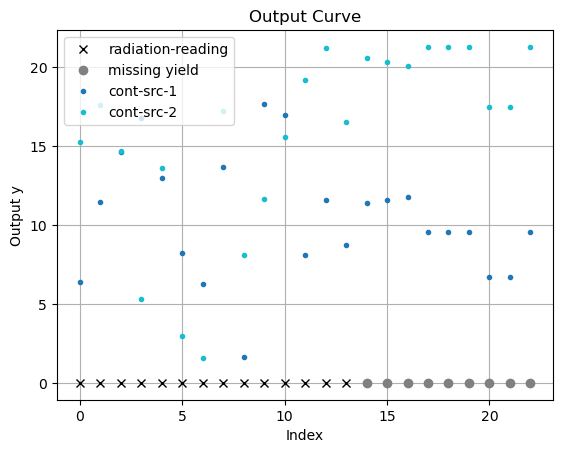

In [8]:
plot_output_points(df_sorted, scale_factor=20.0, yield_scale_factor=1.0)

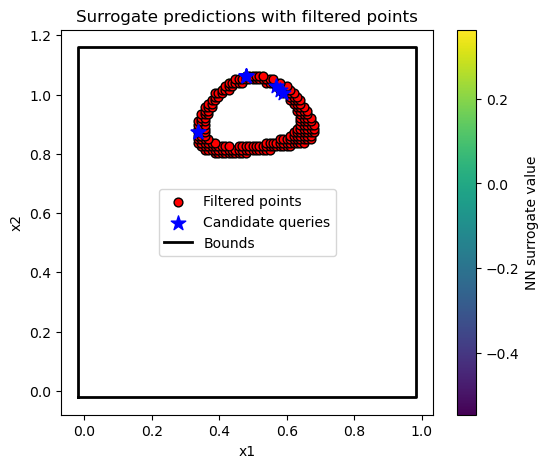

In [ ]:
candidates, labels = extract_candidates_and_labels(query_results, include_score=True)

plot_surrogate_generic(X_grid_filtered, mean, 
                       X_filtered=X_grid_filtered, bounds=bounds, candidates=candidates, candidate_labels=None,
                       title="GP")
